17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Training LSTM model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 339ms/step - accuracy: 0.7664 - loss: 0.4899 - val_accuracy: 0.8548 - val_loss: 0.3436
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 340ms/step - accuracy: 0.8684 - loss: 0.3271 - val_accuracy: 0.8276 - val_loss: 0.3974
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8548 - loss: 0.3436
Test Accuracy: 0.8547599911689758


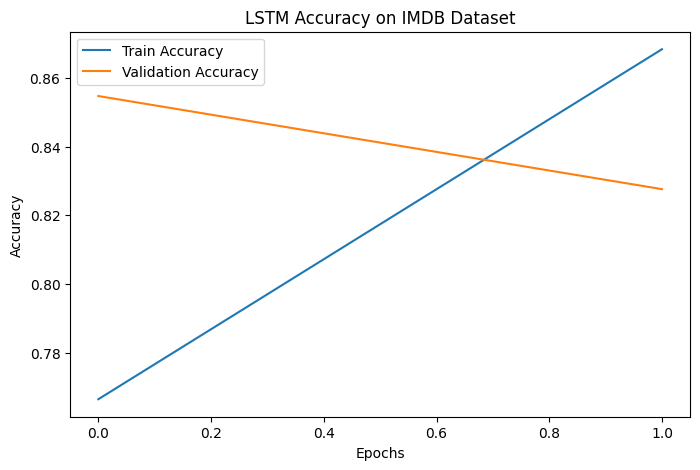

In [1]:
# ================================
# IMDB Sentiment Analysis using LSTM
# ================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# -------------------------------
# Load Dataset
# -------------------------------

vocab_size = 80000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

# -------------------------------
# Padding Sequences
# -------------------------------

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# -------------------------------
# Build LSTM Model
# -------------------------------

def build_lstm():
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=64,
                  input_length=max_len),

        LSTM(64,
             dropout=0.3,
             recurrent_dropout=0.3),

        Dense(1, activation='sigmoid')
    ])

    return model

model = build_lstm()

# -------------------------------
# Compile Model
# -------------------------------

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# -------------------------------
# Early Stopping
# -------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

# -------------------------------
# Train Model
# -------------------------------

print("Training LSTM model...")

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# -------------------------------
# Evaluate Model
# -------------------------------

loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

# -------------------------------
# Plot Accuracy Graph
# -------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy on IMDB Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()